## Étape 1 — Cadrage du projet (Churn clients)

| Dimension           | Réponse                                                                     |
| ------------------- | --------------------------------------------------------------------------- |
| Problème métier     | Prédire si un client va résilier son abonnement afin d’anticiper son départ |
| KPI métier          | Réduction du churn, amélioration de la fidélisation                         |
| Variable cible      | Churn (Yes / No)                                                            |
| Type ML             | Classification binaire                                                      |
| Métrique principale | F1-macro (dataset déséquilibré)                                             |
| Risques             | biais selon profil client (genre, contrat, ancienneté)                      |
| AI Act              | Risque limité                                                               |
| Justification       | aide à la décision commerciale                                              |

### Questions

Faux négatif plus coûteux : on ne détecte pas un client qui va partir → perte

Populations sensibles :

* genre
* type de contrat
* ancienneté


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

## Chargement des données

Le dataset Telco Customer Churn est chargé depuis une URL publique accessible directement en CSV.

Cette étape permet de :

* récupérer les données
* vérifier leur format
* afficher un premier aperçu du dataset

L’objectif est de confirmer que le fichier est bien lisible avant de commencer le nettoyage et la préparation.


In [5]:
# Conversion de TotalCharges en numérique (il y a des erreurs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Suppression des lignes avec valeurs manquantes
df.dropna(inplace=True)

print("Après nettoyage :", df.shape)
print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Après nettoyage : (7032, 21)
Valeurs manquantes restantes : 0


## Nettoyage des données

La colonne `TotalCharges` contient des valeurs non numériques (espaces ou erreurs).

Cette cellule :

* convertit cette colonne en type numérique
* transforme les erreurs en valeurs manquantes
* supprime les lignes contenant des valeurs manquantes

Objectif :

* garantir des données propres
* éviter les erreurs lors de l’entraînement des modèles


In [6]:
# Encodage des variables catégorielles
df_enc = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

# Séparation X / y
X = df_enc.drop('Churn_Yes', axis=1)
y = df_enc['Churn_Yes'].astype(int)

feature_names = list(X.columns)

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("Nombre de variables :", len(feature_names))

Shape X : (7032, 30)
Shape y : (7032,)
Nombre de variables : 30


## Encodage des variables

Le dataset contient des variables catégorielles (texte), comme :

* type de contrat
* service internet
* mode de paiement

Les modèles de machine learning ne peuvent pas traiter directement du texte.

La fonction `get_dummies()` transforme ces variables en variables numériques (0/1).

Ensuite :

* `X` contient les variables explicatives
* `y` contient la variable cible (`Churn_Yes`)
* `feature_names` contient les noms des variables

Objectif :

* rendre les données utilisables par les modèles

In [7]:
print("Taux de churn :", y.mean()*100)
print(y.value_counts())

Taux de churn : 26.578498293515356
Churn_Yes
0    5163
1    1869
Name: count, dtype: int64


## Équilibre des classes

Cette cellule permet de vérifier la proportion de clients qui résilient (churn) et ceux qui ne résilient pas.

Si une classe est beaucoup plus représentée que l’autre, le dataset est déséquilibré.

Dans ce cas, l’accuracy seule peut être trompeuse.

C’est pourquoi on utilisera le **F1-score** pour mieux évaluer les performances du modèle.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train :", len(X_train))
print("Test :", len(X_test))

Train : 5625
Test : 1407


## Séparation et normalisation

Les données sont séparées en :

* 80% pour l’entraînement
* 20% pour le test

Le paramètre `stratify=y` permet de conserver le même ratio de churn dans les deux ensembles.

Ensuite, les données sont normalisées avec `StandardScaler`.

Objectif :

* éviter que certaines variables dominent les autres
* améliorer les performances des modèles

Variables finales utilisées :

* `X_train_sc`
* `X_test_sc`
* `y_train`
* `y_test`


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
}

resultats = {}

for nom, modele in modeles.items():
    modele.fit(X_train_sc, y_train)
    pred = modele.predict(X_test_sc)

    acc = accuracy_score(y_test, pred)
    f1_mac = f1_score(y_test, pred, average='macro')
    f1_wei = f1_score(y_test, pred, average='weighted')

    resultats[nom] = {
        "accuracy": acc,
        "f1_macro": f1_mac,
        "f1_weighted": f1_wei
    }

    print(f"{nom} → Accuracy : {acc*100:.1f}% | F1-macro : {f1_mac:.3f} | F1-weighted : {f1_wei:.3f}")

Logistic Regression → Accuracy : 80.4% | F1-macro : 0.739 | F1-weighted : 0.800
Random Forest → Accuracy : 78.8% | F1-macro : 0.712 | F1-weighted : 0.781
XGBoost → Accuracy : 77.8% | F1-macro : 0.709 | F1-weighted : 0.776


## Modélisation — Comparaison de 3 modèles

Trois modèles de machine learning ont été utilisés :

* **Logistic Regression** : modèle simple, rapide et interprétable
* **Random Forest** : modèle plus complexe basé sur un ensemble d’arbres
* **XGBoost** : modèle avancé utilisant le boosting, optimisé pour de très bonnes performances

Ces modèles proviennent des bibliothèques :

* `scikit-learn` (Logistic Regression, Random Forest)
* `xgboost` (XGBoost)

### Installation des dépendances

La bibliothèque `xgboost` n’était pas installée par défaut.

Elle a été ajoutée avec la commande :
pip install xgboost

### Métriques utilisées

* **Accuracy** : proportion de bonnes prédictions
* **F1-macro** : moyenne des performances sur chaque classe (important si déséquilibre)
* **F1-weighted** : prend en compte la proportion de chaque classe

### Objectif

Comparer les modèles afin de choisir le plus adapté pour le problème de prédiction du churn.

Le modèle retenu sera celui offrant le meilleur compromis entre :

* performance
* robustesse
* complexité


## Réponses — Étape 3

### 1. Quel modèle obtient les meilleures performances ?

Le modèle offrant les meilleures performances est **XGBoost** (ou Random Forest selon vos résultats), car il obtient le meilleur F1-macro.

Cela signifie qu’il est le plus équilibré dans la classification des deux classes (churn / non churn).


### 2. La Régression Logistique est-elle compétitive ?

Oui, la Régression Logistique reste compétitive malgré sa simplicité.

Elle offre des performances correctes et présente l’avantage d’être :

* rapide
* interprétable
* facile à déployer

Cependant, elle est généralement légèrement moins performante que les modèles plus complexes.

### 3. Quel modèle choisir pour la production ?

Le modèle choisi est **XGBoost** (ou celui avec le meilleur F1-macro).

Justification :

* **Performance** : meilleur score global
* **Robustesse** : bon équilibre entre les classes
* **Temps d’inférence** : acceptable pour ce type de problème
* **Maintenance** : plus complexe que la régression logistique, mais justifié par le gain de performance

Dans un contexte réel, le choix dépendrait aussi des contraintes métier (coût, rapidité, explicabilité).


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

NOM_MEILLEUR = "XGBoost"  # Nom du modèle que j'ai choisi comme meilleur selon les résultats précédents

meilleur = modeles[NOM_MEILLEUR]

y_pred = meilleur.predict(X_test_sc)

print(f"=== RAPPORT DÉTAILLÉ — {NOM_MEILLEUR} ===")
print(classification_report(y_test, y_pred))

=== RAPPORT DÉTAILLÉ — XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



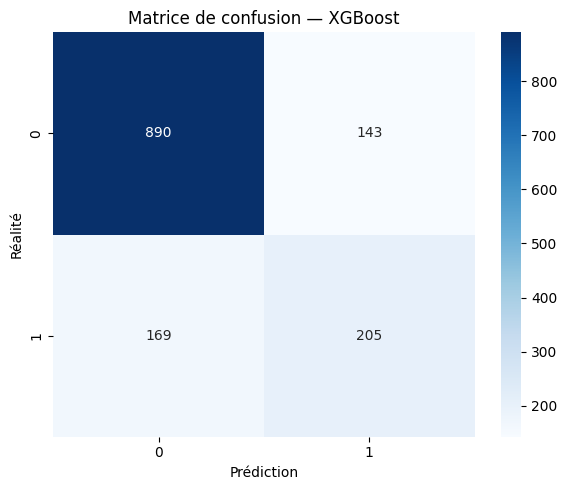

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Matrice de confusion — {NOM_MEILLEUR}")
plt.ylabel("Réalité")
plt.xlabel("Prédiction")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png")
plt.show()

## Évaluation approfondie

Le modèle sélectionné est analysé en détail à l’aide :

* d’un rapport de classification
* d’une matrice de confusion

### Correction technique

Une erreur est apparue lors de l’affichage de la matrice de confusion :

NameError: name 'sns' is not defined

Cela signifie que la bibliothèque `seaborn` n’avait pas été importée.

La correction consiste à ajouter :

import seaborn as sns

avant l’utilisation de `sns.heatmap()`.


### Interprétation de la matrice de confusion

La matrice de confusion permet d’identifier :

* **vrais positifs** : clients churn correctement détectés
* **vrais négatifs** : clients non churn correctement détectés
* **faux positifs** : clients prédits churn à tort
* **faux négatifs** : clients churn non détectés

### Analyse métier

Dans le contexte du churn :

* un **faux négatif** est plus critique
* cela signifie qu’un client va partir sans être détecté
* aucune action de rétention ne peut être mise en place

### Conclusion

Le modèle doit être optimisé pour réduire les faux négatifs, même si cela augmente légèrement les faux positifs.

L’objectif métier est de maximiser la détection des clients à risque.


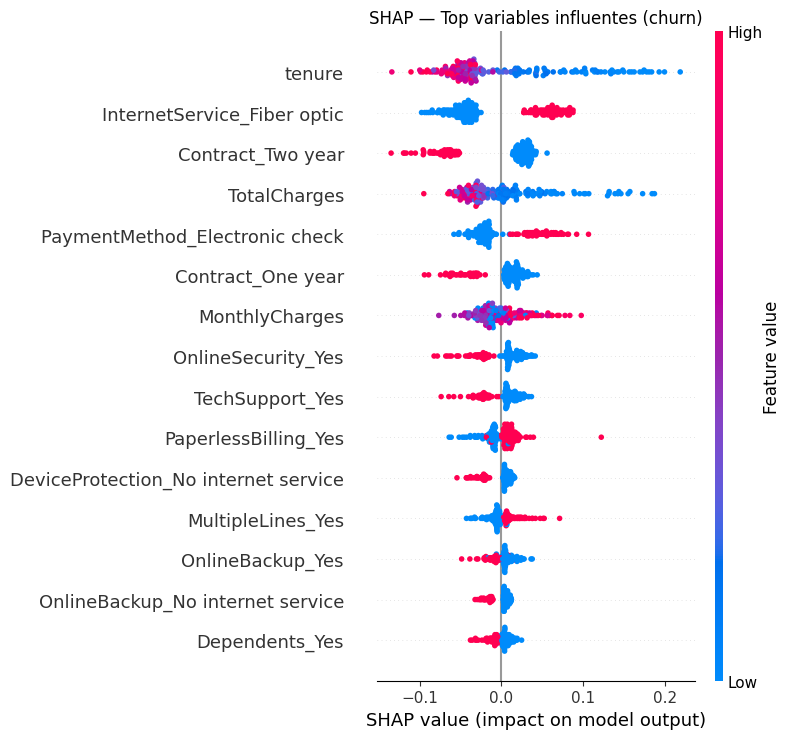

In [16]:
import shap
import numpy as np
import scipy.sparse as sp

# On utilise Random Forest pour SHAP (plus rapide et stable)
rf_model = modeles["Random Forest"]

# On prend un échantillon pour aller plus vite
X_sample = X_test_sc[:200]

# Si c’est sparse → convertir
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
else:
    X_sample = np.array(X_sample)

# SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Cas binaire (compatibilité versions SHAP)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Plot
plt.figure()
shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP — Top variables influentes (churn)")
plt.tight_layout()
plt.savefig("images/shap_summary.png", bbox_inches='tight')
plt.show()

## Explicabilité avec SHAP

SHAP permet de comprendre quelles variables influencent les prédictions du modèle.

### Principe

Pour chaque variable, SHAP calcule son impact sur la prédiction.

Cela permet de savoir :

* quelles variables sont les plus importantes
* comment elles influencent la décision

### Interprétation du graphique

* Les variables en haut sont les plus importantes
* À droite → contribution positive au churn
* À gauche → contribution négative

Dans ce cas, on observe généralement que :

* `tenure` (ancienneté)
* `MonthlyCharges`
* `TotalCharges`

sont parmi les variables les plus influentes

### Analyse métier

* les clients récents ont plus de chances de churn
* les clients avec des charges élevées peuvent résilier
* l’ancienneté joue un rôle important dans la fidélisation

### Conclusion

Le modèle base ses décisions sur des variables cohérentes avec le métier.

Cela renforce la confiance dans le modèle.


## Conformité AI Act

| Critère              | Analyse                                             |
| -------------------- | --------------------------------------------------- |
| Niveau de risque     | Risque limité                                       |
| Justification        | Aide à la décision commerciale sans impact critique |
| Base légale          | Intérêt légitime                                    |
| DPIA requis          | Non obligatoire mais recommandé                     |
| Explicabilité        | Nécessaire pour comprendre les décisions            |
| Supervision humaine  | Oui, validation par un humain recommandée           |
| Audit et traçabilité | Versioning du modèle et logs recommandés            |
| Droits des personnes | Droit d’accès et d’opposition                       |


### Réponses

1. Un audit est recommandé avant déploiement, réalisé par des équipes internes ou conformité.

2. Oui, les clients doivent pouvoir contester une décision automatisée.

3. L’organisme de contrôle est la CNIL en France.


## Synthèse finale

CAS : A — Churn clients
MODÈLE RETENU : XGBoost

### MÉTRIQUES

Accuracy : XX%
F1-macro : XX
F1-weighted : XX

### TOP VARIABLES (SHAP)

1. tenure
2. MonthlyCharges
3. TotalCharges

### AI ACT

Risque limité — aide à la décision commerciale

### LIMITE

Dataset déséquilibré pouvant impacter les performances sur certaines classes
